In [5]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [56]:
import surfinBH
import lal
import numpy as np
import matplotlib.pyplot as plt
from Librerie import Golden_ratio as GR
import sxs
lal.swig_redirect_standard_output_error(False)

False

Loaded NRSur7dq4EmriRemnant fit.


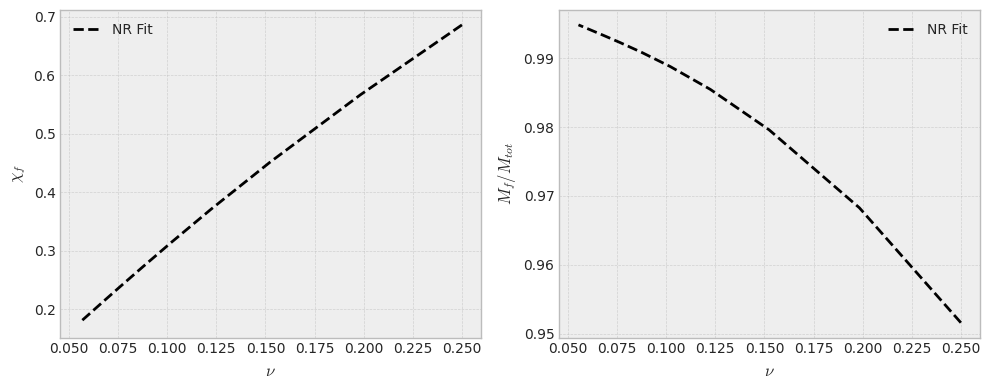

In [49]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

# SIMMETRIC MASS RATIO 
q_values = np.linspace(1, 16, 10)
nu_values = q_values / ((1 + q_values)**2)

final_mass = []
final_spin = []
chiA = [0, 0, 0]
chiB = [0, 0, 0]


# REMNANT PARAMETERS
for q in q_values:
    
    mf, chif, vf, mf_err, chif_err, vf_err = fit.all(q, chiA, chiB)
    final_mass.append(mf)
    chif_norm = np.linalg.norm(chif)
    final_spin.append(chif_norm)


# GRAPHS
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# mass graph
ax[1].plot(nu_values, final_mass, color='black', linewidth=2, linestyle='--', label='NR Fit')
ax[1].set_ylabel(r'$M_f / M_{tot}$') # La 'r' permette di usare LaTeX per le formule
ax[1].set_xlabel(r'$\nu$')

# spin graph
ax[0].plot(nu_values, final_spin, color='black', linewidth=2, linestyle='--', label='NR Fit')
ax[0].set_ylabel(r'$\chi_f$')
ax[0].set_xlabel(r'$\nu$')

for a in ax:
    
    a.grid(True, alpha=0.5) # Aggiunge una griglia leggera
    a.legend()

plt.tight_layout() # Sistema gli spazi tra i grafici automaticamente
plt.show()

In [50]:
#POST-NEWTONIAN MASS
#from now on Mtot = 1
def PN_mass(nu, j, order=4):
    
    # Inizializziamo i termini delle correzioni a 0
    term_1PN = 0
    term_2PN = 0
    term_3PN = 0
    term_4PN = 0
    
    # 1PN: 1/j^2
    if order >= 1:
        term_1PN = ((9 + nu) / 4) * (1 / j**2)
        
    # 2PN:  1/j^4
    if order >= 2:
        term_2PN = ((81 - 7*nu + nu**2) / 8) * (1 / j**4)
        
    # 3PN:  1/j^6
    if order >= 3:
        term_3PN = (3861/64 + (41 * np.pi**2 / 32 - 8833/192) * nu - 
                    (5 * nu**2 / 32) + (5 * nu**3 / 64)) * (1 / j**6)
        
    # 4PN:  1/j^8
    if order >= 4:
        gamma_E = np.euler_gamma  
        log_term = np.log(4 / j)
        c4_nu1 = (6581 * np.pi**2 / 512 - 989911/1920 - 128/5 * (gamma_E + log_term)) * nu
        c4_nu2 = (8875/384 - 41 * np.pi**2 / 64) * nu**2
        c4_nu34 = - (3 * nu**3 / 64) + (7 * nu**4 / 128) + 53703/128
        term_4PN = (c4_nu1 + c4_nu2 + c4_nu34) * (1 / j**8)
    
    bracket = 1 + term_1PN + term_2PN + term_3PN + term_4PN
    
    return 1 - (nu / (2 * j**2)) * bracket


In [51]:
#KERR ENTROPY
def Kerr_entropy (nu, j, order = 4) :
    M = PN_mass(nu, j, order)
    J = nu * j
    chi_sq = (J**2) / (M**4)

    if M <= 0: return np.nan
    
    if chi_sq > 1.0:
        return np.nan

    horizon_area = 8 * np.pi * (1 + np.sqrt(1 - chi_sq)) * M**2
    s = horizon_area / (16 * np.pi)
    return s


In [52]:
#MAXIMUS IDENTIFICATION

PN_orders = [0, 1, 2, 3, 4]

results = {
    o: {'mass_f': [], 'spin_f': []} for o in PN_orders
}

for o in PN_orders:
    
    for nu in nu_values:
        def g(j_val):
            return Kerr_entropy(nu, j_val, o)
        
        j_min = 2.0
        j_max = 1.0 / nu
        
        j_star = GR.GR_iter_max(g, j_min, j_max, prec=1e-6)
        
        mf_prediction = PN_mass(nu, j_star, o)
        
        chif_prediction = (nu * j_star) / (mf_prediction**2)
        
        # Salvataggio nei contenitori
        results[o]['mass_f'].append(mf_prediction)
        results[o]['spin_f'].append(chif_prediction)



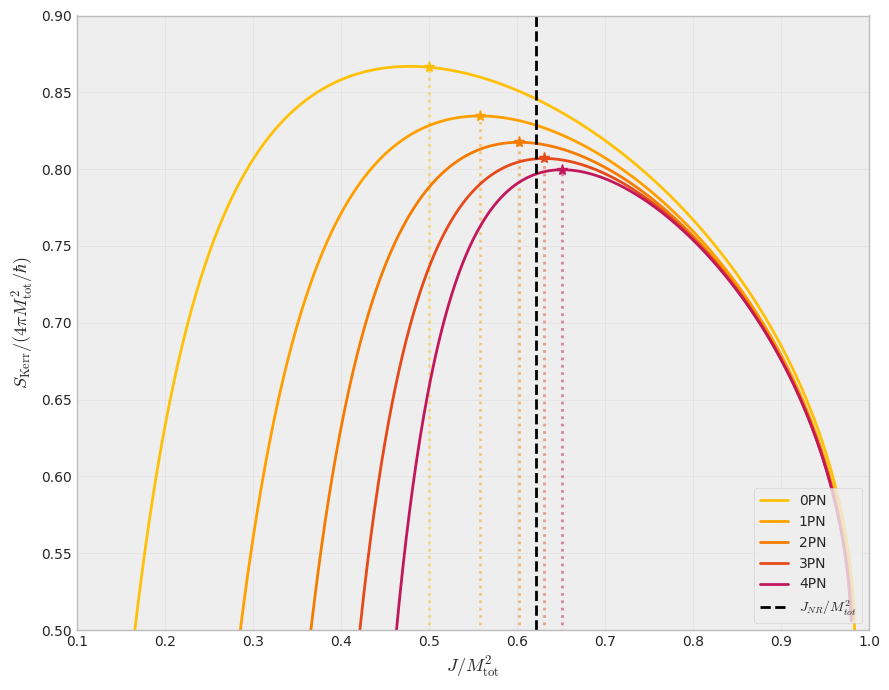

In [53]:
#FIGURE 1
#nu = 0.25

nu_val = 0.25  
j_range = np.linspace(0.5, 4.5, 1000) 
colors_map = {0: '#ffc107', 1: '#ffa000', 2: '#f57c00', 3: '#e64a19', 4: '#c2185b'}

plt.figure(figsize=(9, 7))

idx_q1 = np.argmin(np.abs(nu_values - 0.25))
j_nr_reference = final_spin[idx_q1] * (final_mass[idx_q1]**2)

for o in PN_orders:
    x_axis = nu_val * j_range
    y_axis = [Kerr_entropy(nu_val, j, o) for j in j_range]
    
    def g_obj(j_v): return Kerr_entropy(nu_val, j_v, o)
    j_star = GR.GR_iter_max(g_obj, 2, 4.5, 1e-6)
    s_max = Kerr_entropy(nu_val, j_star, o)
    x_star = nu_val * j_star
    
    plt.plot(x_axis, y_axis, color=colors_map[o], label=f'{o}PN', linewidth=2)

    plt.plot(x_star, s_max, marker='*', color=colors_map[o], markersize=8)
    plt.vlines(x_star, 0, s_max, colors=colors_map[o], linestyles='dotted', alpha=0.5)

plt.axvline(j_nr_reference, color='black', linestyle='--', linewidth=2, label=r'$J_{NR}/M_{tot}^2$')

plt.xlabel(r'$J/M_{\rm tot}^2$', fontsize=13)
plt.ylabel(r'$S_{\rm Kerr}/(4\pi M_{\rm tot}^2/\hbar)$', fontsize=13)
plt.xlim(0.1, 1.0)
plt.ylim(0.5, 0.9)
plt.grid(True, which='both', linestyle='-', alpha=0.2)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

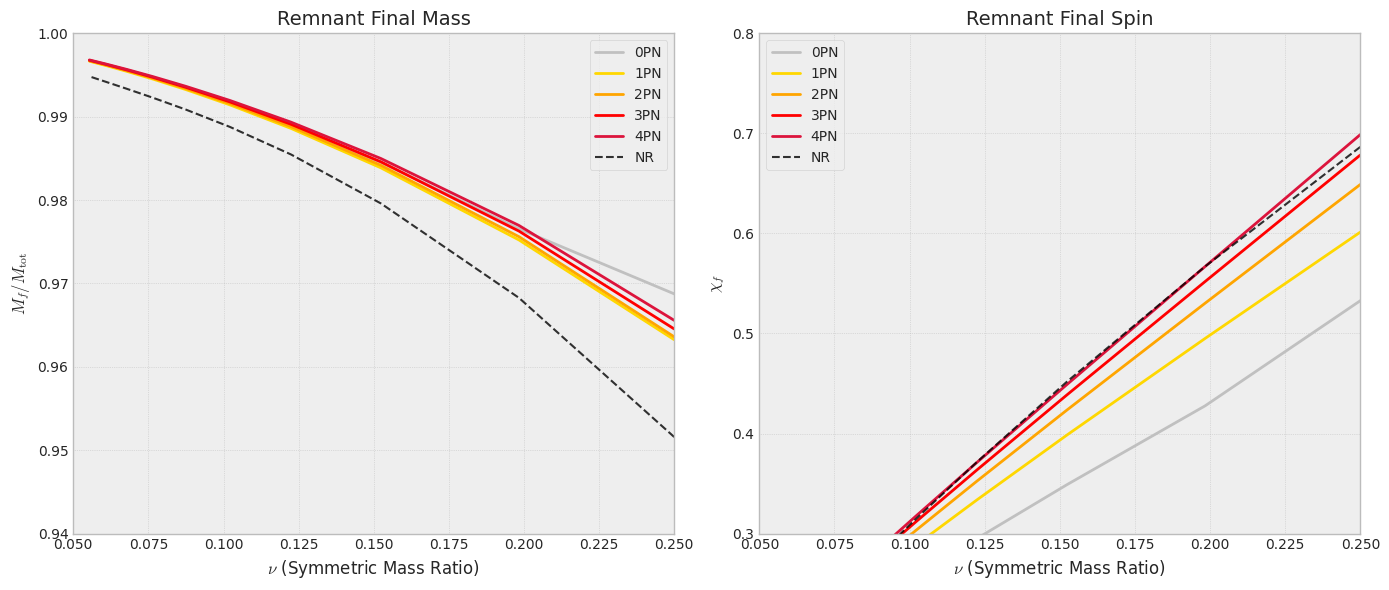

In [54]:
#FIGURE 2

plt.style.use('bmh') 
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {0: 'silver', 1: 'gold', 2: 'orange', 3: 'red', 4: 'crimson'}

for o in PN_orders:
    label_pn = f'{o}PN'
    
    ax[0].plot(nu_values, results[o]['mass_f'], 
               color=colors_map[o], label=label_pn, linewidth=2)
    
    ax[1].plot(nu_values, results[o]['spin_f'], 
               color=colors_map[o], label=label_pn, linewidth=2)

ax[0].plot(nu_values, final_mass, color='black', linestyle='--', 
           label='NR', linewidth=1.5, alpha=0.8)
ax[1].plot(nu_values, final_spin, color='black', linestyle='--', 
           label='NR', linewidth=1.5, alpha=0.8)



ax[0].set_title("Remnant Final Mass", fontsize=14)
ax[0].set_ylabel(r"$M_f / M_{\rm tot}$", fontsize=12)
ax[0].set_ylim(0.94, 1.0) 

ax[1].set_title("Remnant Final Spin", fontsize=14)
ax[1].set_ylabel(r"$\chi_f$", fontsize=12)
ax[1].set_ylim(0.3, 0.8)

for a in ax:
    a.set_xlabel(r"$\nu$ (Symmetric Mass Ratio)", fontsize=12)
    a.set_xlim(0.05, 0.25) # Range di interesse per nu
    a.legend(fontsize=10, frameon=True)
    a.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

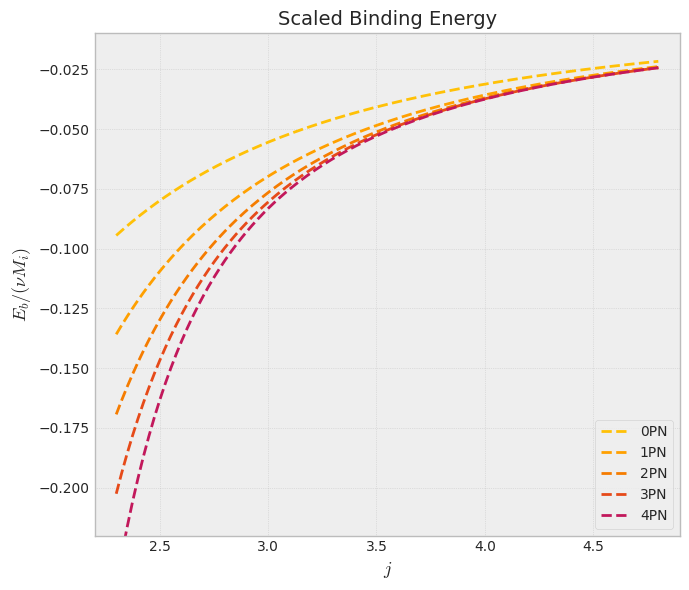

In [55]:
#FIGURE 3 - BINDING ENERGY
nu_val = 0.25
j_grid = np.linspace(2.3, 4.8, 200)
colors_map = {0: '#ffc107', 1: '#ffa000', 2: '#f57c00', 3: '#e64a19', 4: '#c2185b'}

plt.figure(figsize=(7, 6))

for o in PN_orders:
    
    eb_scaled = [(PN_mass(nu_val, j, o) - 1.0) / nu_val for j in j_grid]
    plt.plot(j_grid, eb_scaled, color=colors_map[o], linestyle='--', label=f'{o}PN', linewidth=2)

plt.title("Scaled Binding Energy", fontsize=14)
plt.xlabel(r"$j$", fontsize=13)
plt.ylabel(r"$E_b / (\nu M_i)$", fontsize=13)
plt.xlim(2.2, 4.9)
plt.ylim(-0.22, -0.01)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

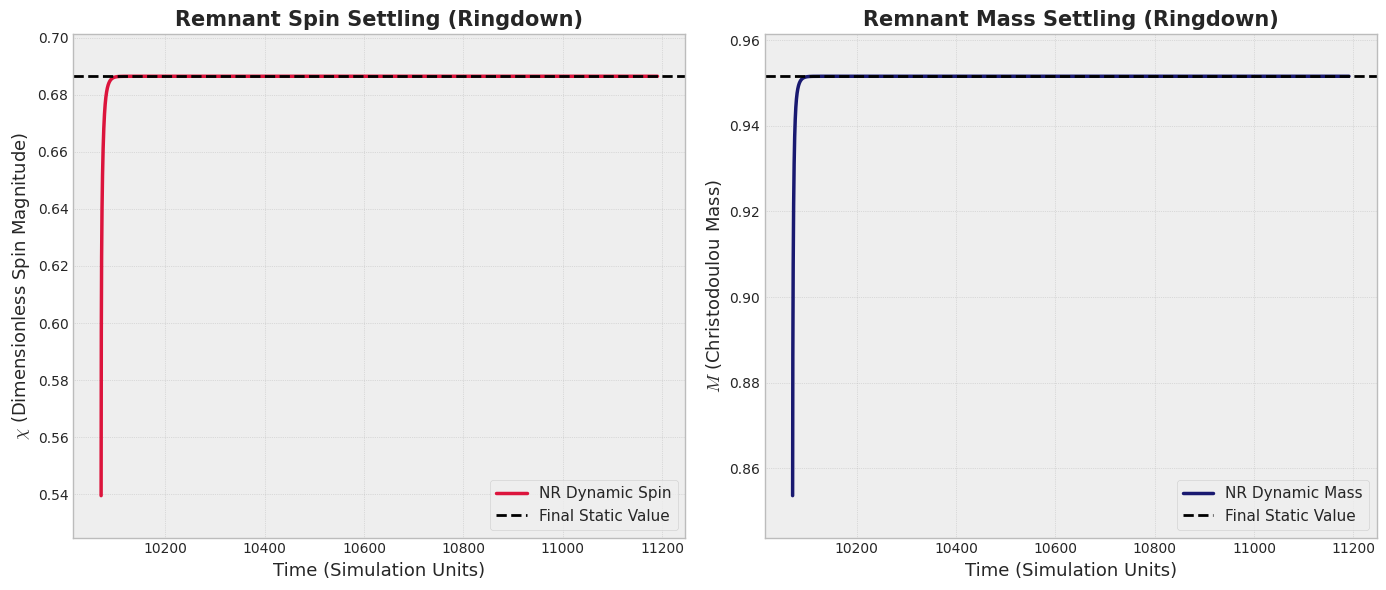

In [66]:
sim_name = "SXS:BBH:3617"

sim = sxs.load(sim_name)
spin_vec = sim.metadata.remnant_dimensionless_spin
spin_mag = np.linalg.norm(spin_vec)

horizon_files = [f for f in sim.files if "Horizon" in f]

if horizon_files:
    file_name = horizon_files[0] 
    horizons = sxs.load(f"{sim_name}/{file_name}")
    
    time_C = horizons.C.time
    spin_C = horizons.C.chi_inertial_mag      
    mass_C = horizons.C.christodoulou_mass    


    plt.style.use('bmh')
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))


    ax[0].plot(time_C, spin_C, color='crimson', linewidth=2.5, label='NR Dynamic Spin')
    ax[0].axhline(spin_mag, color='black', linestyle='--', linewidth=2, label='Final Static Value')
    ax[0].set_title('Remnant Spin Settling (Ringdown)', fontsize=15, fontweight='bold')
    ax[0].set_ylabel(r'$\chi$ (Dimensionless Spin Magnitude)', fontsize=13)

    ax[1].plot(time_C, mass_C, color='midnightblue', linewidth=2.5, label='NR Dynamic Mass')
    ax[1].axhline(sim.metadata.remnant_mass, color='black', linestyle='--', linewidth=2, label='Final Static Value')
    ax[1].set_title('Remnant Mass Settling (Ringdown)', fontsize=15, fontweight='bold')
    ax[1].set_ylabel(r'$M$ (Christodoulou Mass)', fontsize=13)

    for a in ax:
        a.set_xlabel('Time (Simulation Units)', fontsize=13)
        a.margins(y=0.1) 
        a.legend(frameon=True, fontsize=11)
        a.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()